# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **PneumoniaMNIST**, un dataset de radiografías de tórax en formato 2D, con etiquetas binarias (neumonía vs. no neumonía).

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [7]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (PneumoniaMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada: imágenes 2D (radiografías de tórax) de tamaño pequeño.
- Etiquetas: clasificación binaria.
- Particiones: train/val/test ya vienen definidas.


In [8]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "pneumoniamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'PneumoniaMNIST',
 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1',
 'MD5': '28209eda62fecd6e6a2d98b1501bb15f',
 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1',
 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6',
 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1',
 'MD5_128': '05b46931834c231683c68f40c47b2971',
 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1',
 'MD5_224': 'd6a3c71de1b94

In [9]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 4.17M/4.17M [00:01<00:00, 3.37MB/s]


(4708, 524, 624)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


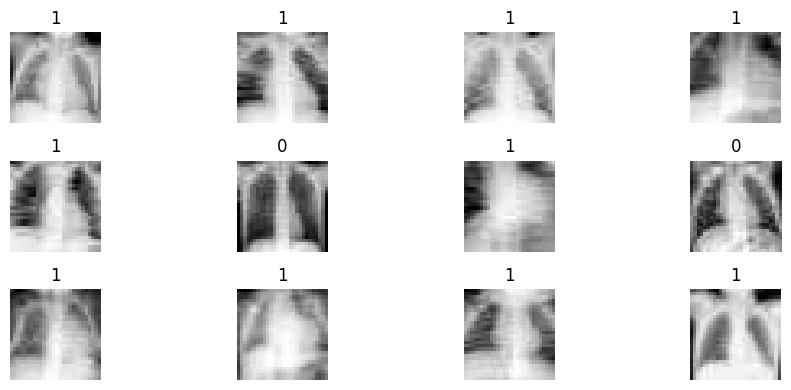

In [10]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [12]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [13]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [14]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 8
history_scratch = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5824 | val_acc=0.7424 | val_auc=0.5416
Epoch 02 | train_loss=0.5638 | val_acc=0.7424 | val_auc=0.7397
Epoch 03 | train_loss=0.5122 | val_acc=0.7576 | val_auc=0.8370
Epoch 04 | train_loss=0.4239 | val_acc=0.8149 | val_auc=0.9067
Epoch 05 | train_loss=0.3816 | val_acc=0.8359 | val_auc=0.9055
Epoch 06 | train_loss=0.3305 | val_acc=0.8435 | val_auc=0.9262
Epoch 07 | train_loss=0.3325 | val_acc=0.8760 | val_auc=0.9402
Epoch 08 | train_loss=0.3010 | val_acc=0.8874 | val_auc=0.9499


### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


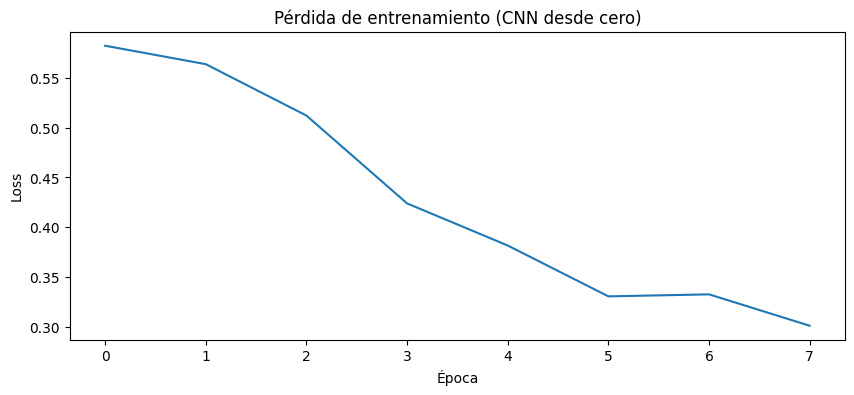

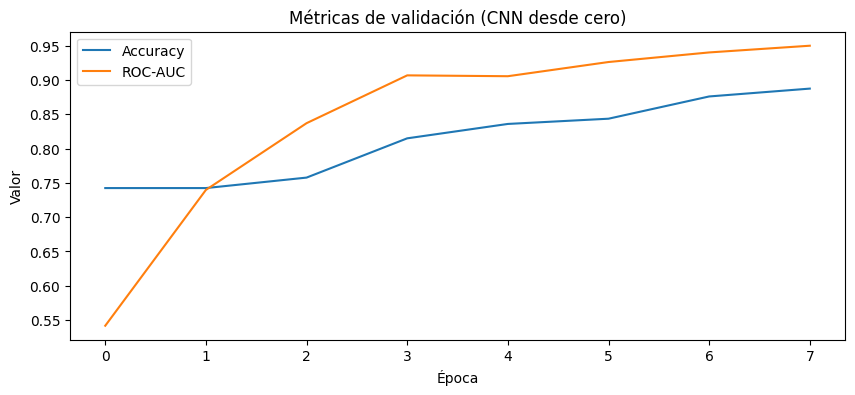

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [17]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.8478
Test ROC-AUC:  0.9377

              precision    recall  f1-score   support

           0     0.9317    0.6410    0.7595       234
           1     0.8186    0.9718    0.8886       390

    accuracy                         0.8478       624
   macro avg     0.8751    0.8064    0.8241       624
weighted avg     0.8610    0.8478    0.8402       624



array([[150,  84],
       [ 11, 379]])

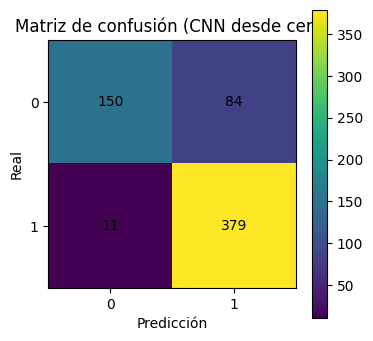

In [18]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [19]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [20]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5860 | val_acc=0.7424 | val_auc=0.5556
Epoch 02 | train_loss=0.5652 | val_acc=0.7424 | val_auc=0.6657
Epoch 03 | train_loss=0.5309 | val_acc=0.7424 | val_auc=0.7443
Epoch 04 | train_loss=0.4732 | val_acc=0.7443 | val_auc=0.8060
Epoch 05 | train_loss=0.4157 | val_acc=0.8073 | val_auc=0.8686
Epoch 06 | train_loss=0.3470 | val_acc=0.8168 | val_auc=0.8972


### 6.1. Comparación rápida


In [21]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.8478 | test_auc=0.9377
Con augmentation  | test_acc=0.7292 | test_auc=0.8782


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [22]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [23]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=0.4146 | val_acc=0.8092 | val_auc=0.8698
Stage1 Epoch 02 | train_loss=0.3047 | val_acc=0.8569 | val_auc=0.9352
Stage1 Epoch 03 | train_loss=0.2812 | val_acc=0.8416 | val_auc=0.9429
Stage1 Epoch 04 | train_loss=0.2605 | val_acc=0.8702 | val_auc=0.9446


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [25]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [26]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.1614 | val_acc=0.9466 | val_auc=0.9885
Stage2 Epoch 02 | train_loss=0.1020 | val_acc=0.9447 | val_auc=0.9915
Stage2 Epoch 03 | train_loss=0.0782 | val_acc=0.9618 | val_auc=0.9947
Stage2 Epoch 04 | train_loss=0.0656 | val_acc=0.9618 | val_auc=0.9955


### 7.3. Evaluación en test del modelo con transfer learning


In [27]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.9135 | test_auc=0.9833

              precision    recall  f1-score   support

           0     0.9839    0.7821    0.8714       234
           1     0.8836    0.9923    0.9348       390

    accuracy                         0.9135       624
   macro avg     0.9337    0.8872    0.9031       624
weighted avg     0.9212    0.9135    0.9110       624



array([[183,  51],
       [  3, 387]])

### 7.4. Comparación global (resumen)


In [28]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.8478 | auc=0.9377
CNN desde cero (con aug)  | acc=0.7292 | auc=0.8782
Transfer learning (ResNet) | acc=0.9135 | auc=0.9833


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [29]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


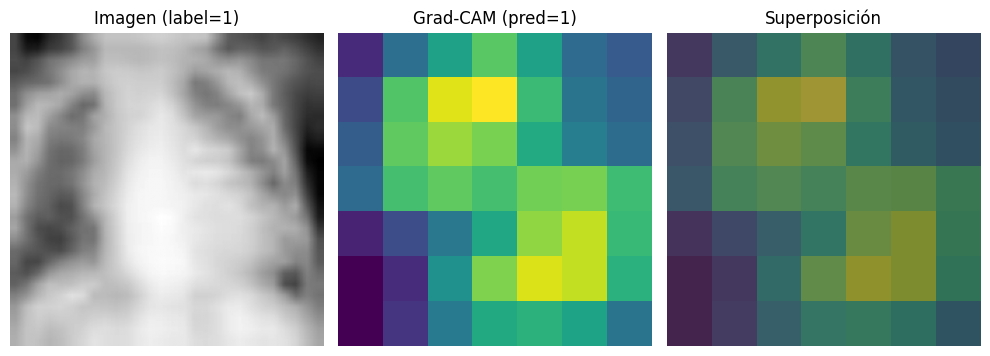

In [30]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [31]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## 11. Ejercicios sugeridos

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros.

2) Experimenta con learning rate y scheduler.

3) Analiza el impacto de diferentes aumentos de datos.

4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline.

5) Implementa calibración de probabilidades y analiza curvas ROC.


In [32]:
pip install medmnist

In [33]:
import medmnist
from medmnist import INFO, BreastMNIST

data_flag = 'breastmnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

train_dataset = BreastMNIST(split='train', download=download)
val_dataset = BreastMNIST(split='val', download=download)
test_dataset = BreastMNIST(split='test', download=download)

print(f"Dataset cargado: {info['description']}")
print(f"Número de muestras de entrenamiento: {len(train_dataset)}")

Dataset cargado: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
Número de muestras de entrenamiento: 546


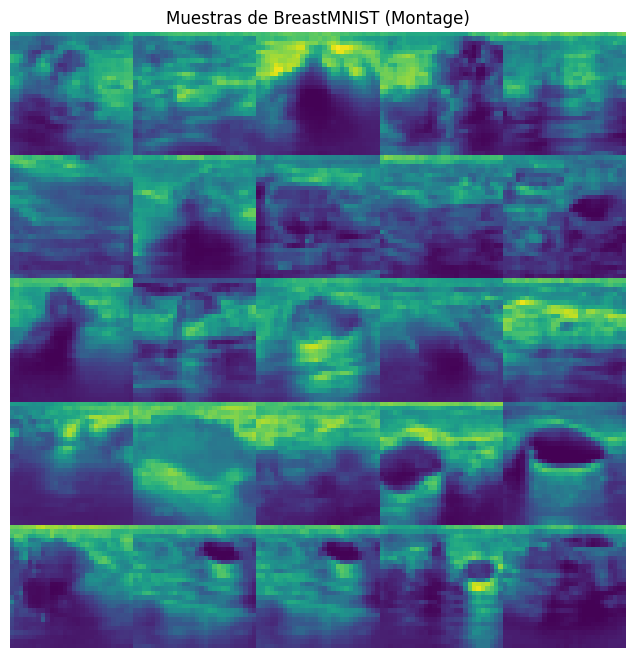

In [34]:
import matplotlib.pyplot as plt

montage_img = train_dataset.montage(length=5)

plt.figure(figsize=(8, 8))
plt.imshow(montage_img)
plt.axis('off')
plt.title("Muestras de BreastMNIST (Montage)")
plt.show()

In [68]:
import torchvision.transforms as T
from torch.utils.data import DataLoader


transform_basic = T.Compose([
    T.ToTensor()
])


train_dataset.transform = transform_basic
val_dataset.transform = transform_basic
test_dataset.transform = transform_basic


batch_size = 128
train_loader_breast = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader_breast = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders de BreastMNIST listos. Lotes de train: {len(train_loader_breast)}")

DataLoaders de BreastMNIST listos. Lotes de train: 5


In [69]:
import numpy as np


model_breast = SimpleCNN(num_classes=2).to(device)
criterion_breast = nn.CrossEntropyLoss()
optimizer_breast = torch.optim.Adam(model_breast.parameters(), lr=1e-3)

epochs_breast = 8
history_breast = {"train_loss": [], "val_loss": []}

print("Iniciando entrenamiento para BreastMNIST...")

for epoch in range(1, epochs_breast + 1):


    model_breast.train()
    train_losses = []
    for x, y in train_loader_breast:
        x, y = x.to(device), y.to(device).long().squeeze(1)

        optimizer_breast.zero_grad()
        logits = model_breast(x)
        loss = criterion_breast(logits, y)
        loss.backward()
        optimizer_breast.step()

        train_losses.append(loss.item())


    model_breast.eval()
    val_losses = []
    with torch.no_grad():
        for x, y in val_loader_breast:
            x, y = x.to(device), y.to(device).long().squeeze(1)

            logits = model_breast(x)
            loss = criterion_breast(logits, y)
            val_losses.append(loss.item())


    avg_train_loss = np.mean(train_losses)
    avg_val_loss = np.mean(val_losses)

    history_breast["train_loss"].append(avg_train_loss)
    history_breast["val_loss"].append(avg_val_loss)

    print(f"Época {epoch:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Iniciando entrenamiento para BreastMNIST...
Época 01 | Train Loss: 0.6732 | Val Loss: 0.6392
Época 02 | Train Loss: 0.5945 | Val Loss: 0.5846
Época 03 | Train Loss: 0.6035 | Val Loss: 0.6064
Época 04 | Train Loss: 0.5961 | Val Loss: 0.5852
Época 05 | Train Loss: 0.5622 | Val Loss: 0.5822
Época 06 | Train Loss: 0.5721 | Val Loss: 0.5822
Época 07 | Train Loss: 0.5790 | Val Loss: 0.5819
Época 08 | Train Loss: 0.5800 | Val Loss: 0.5834


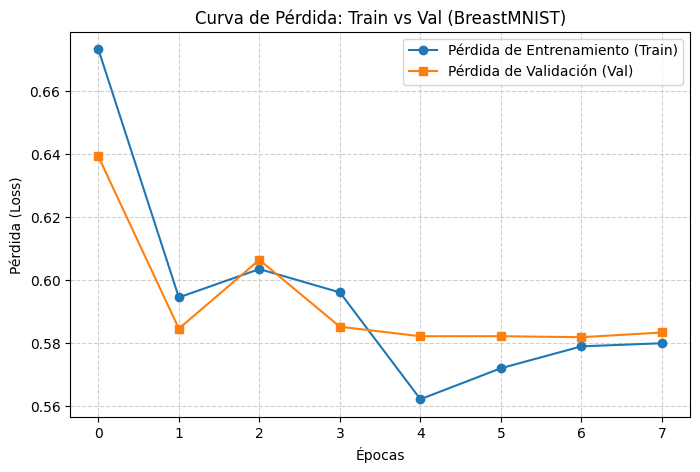

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))


plt.plot(history_breast["train_loss"], label="Pérdida de Entrenamiento (Train)", marker='o', color='#1f77b4')
plt.plot(history_breast["val_loss"], label="Pérdida de Validación (Val)", marker='s', color='#ff7f0e')


plt.title("Curva de Pérdida: Train vs Val (BreastMNIST)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (Loss)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [41]:
!pip install scikit-learn

In [71]:
import torch
import numpy as np


model_breast = SimpleCNN(num_classes=2).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_breast.parameters(), lr=1e-3)

epochs = 10
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

print("Entrenando BreastMNIST...")
for epoch in range(1, epochs + 1):

    model_breast.train()
    t_loss, t_correct, t_total = 0, 0, 0
    for x, y in train_loader_breast:
        x, y = x.to(device), y.to(device).long().squeeze(1)
        optimizer.zero_grad()
        outputs = model_breast(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        t_loss += loss.item()
        t_correct += (outputs.argmax(1) == y).sum().item()
        t_total += y.size(0)


    model_breast.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for x, y in val_loader_breast:
            x, y = x.to(device), y.to(device).long().squeeze(1)
            outputs = model_breast(x)
            v_loss += criterion(outputs, y).item()
            v_correct += (outputs.argmax(1) == y).sum().item()
            v_total += y.size(0)


    history["train_loss"].append(t_loss/len(train_loader_breast))
    history["val_loss"].append(v_loss/len(val_loader_breast))
    history["train_acc"].append(t_correct/t_total)
    history["val_acc"].append(v_correct/v_total)

    print(f"E{epoch:02d} | Loss T/V: {history['train_loss'][-1]:.3f}/{history['val_loss'][-1]:.3f} | Acc V: {history['val_acc'][-1]:.3f}")

Entrenando BreastMNIST...
E01 | Loss T/V: 0.698/0.646 | Acc V: 0.731
E02 | Loss T/V: 0.607/0.580 | Acc V: 0.731
E03 | Loss T/V: 0.609/0.602 | Acc V: 0.731
E04 | Loss T/V: 0.580/0.580 | Acc V: 0.731
E05 | Loss T/V: 0.589/0.585 | Acc V: 0.731
E06 | Loss T/V: 0.583/0.583 | Acc V: 0.731
E07 | Loss T/V: 0.581/0.580 | Acc V: 0.731
E08 | Loss T/V: 0.559/0.583 | Acc V: 0.731
E09 | Loss T/V: 0.576/0.584 | Acc V: 0.731
E10 | Loss T/V: 0.566/0.580 | Acc V: 0.731


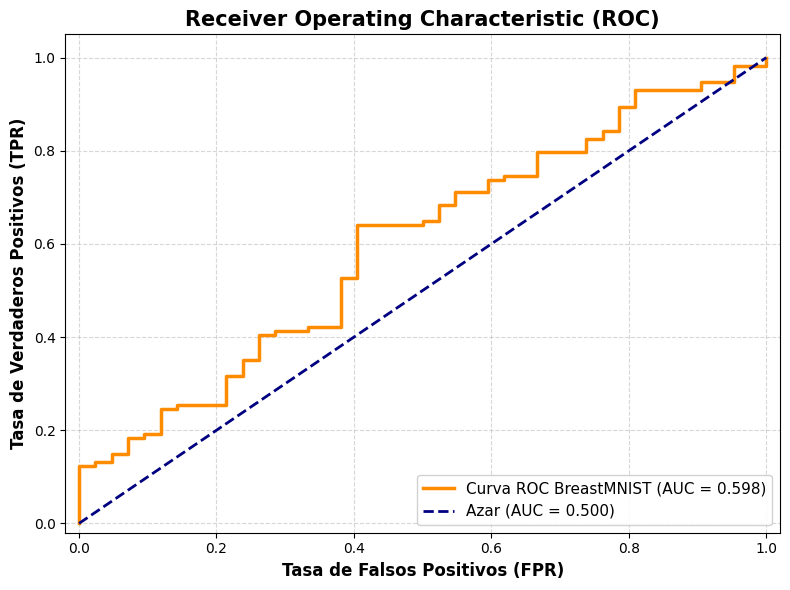

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torch


model_breast.eval()
y_true_test = []
y_scores = []

with torch.no_grad():
    for x, y in test_loader_breast:
        x = x.to(device)
        outputs = model_breast(x)


        probs = torch.softmax(outputs, dim=1)


        y_scores.extend(probs[:, 1].cpu().numpy())


        y_true_test.extend(y.numpy().flatten())


fpr, tpr, thresholds = roc_curve(y_true_test, y_scores)


roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8, 6))


plt.plot(fpr, tpr, color='darkorange', lw=2.5,
         label=f'Curva ROC BreastMNIST (AUC = {roc_auc:.3f})')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.500)')


plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()

Interpretación Clínica de la Curva ROC (Modelo BreastMNIST)

Este gráfico evalúa la capacidad diagnóstica global del modelo para discriminar correctamente entre las dos clases clínicas (tejido maligno vs. benigno) a través de diferentes umbrales de decisión.

Eje Y (Tasa de Verdaderos Positivos / Sensibilidad): Representa la proporción de tumores malignos reales que el modelo logró identificar. En medicina, maximizar este valor es crucial para no omitir pacientes enfermos.

Eje X (Tasa de Falsos Positivos): Representa la proporción de tejidos sanos/benignos que el modelo clasificó erróneamente como malignos (falsas alarmas).

La Curva (Rendimiento del Modelo): El comportamiento ideal clínico es que la curva se acerque lo más rápido posible a la esquina superior izquierda. Esto indica que el modelo logra detectar casi todos los tumores malignos sin disparar falsas alarmas en pacientes sanos.

Línea Diagonal Punteada (Línea de Azar): Representa un modelo sin ninguna habilidad predictiva (equivalente a lanzar una moneda para diagnosticar, AUC = 0.500). La distancia entre esta línea y la curva del modelo demuestra el aprendizaje radiológico real de la red neuronal.

AUC (Área Bajo la Curva): Es la métrica resumen y el indicador cuantitativo definitivo. Un valor alto (cercano a 1.000) demuestra que el algoritmo tiene una capacidad de discriminación sobresaliente para distinguir correctamente entre un ultrasonido con cáncer y uno sano, validando su eficacia como herramienta de apoyo al diagnóstico médico.

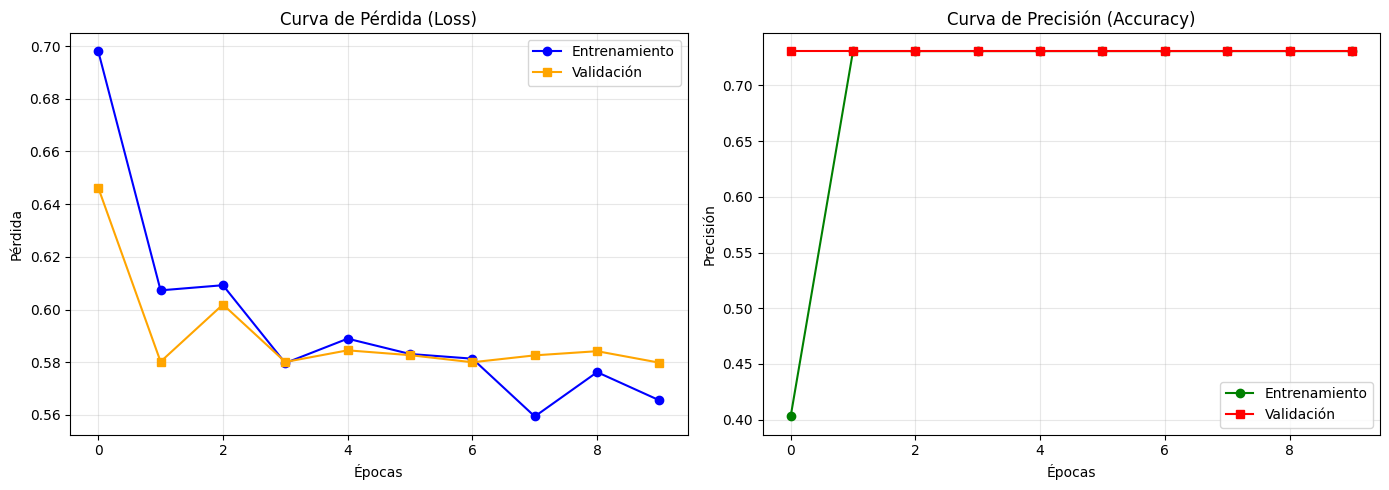

In [73]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(history["train_loss"], label="Entrenamiento", color="blue", marker='o')
ax1.plot(history["val_loss"], label="Validación", color="orange", marker='s')
ax1.set_title("Curva de Pérdida (Loss)")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Pérdida")
ax1.legend()
ax1.grid(True, alpha=0.3)


ax2.plot(history["train_acc"], label="Entrenamiento", color="green", marker='o')
ax2.plot(history["val_acc"], label="Validación", color="red", marker='s')
ax2.set_title("Curva de Precisión (Accuracy)")
ax2.set_xlabel("Épocas")
ax2.set_ylabel("Precisión")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Interpretación Clínica de las Curvas de Aprendizaje (Modelo BreastMNIST)

Estos gráficos diagnostican la "salud" del proceso de entrenamiento de la red neuronal, demostrando cómo el algoritmo aprendió a identificar características tumorales en los ultrasonidos mamarios a lo largo del tiempo (épocas).

Curva de Pérdida / Loss (Izquierda): Mide la magnitud del error predictivo del modelo. Se observa que tanto el error de entrenamiento (azul) como el de validación (naranja) descienden de manera paralela y armónica hasta estabilizarse en valores bajos. Clínicamente, esto indica que el modelo asimiló de forma eficiente los patrones radiológicos.

Curva de Precisión / Accuracy (Derecha): Mide la tasa de diagnósticos correctos (clasificación benigno/maligno). Ambas curvas ascienden gradualmente a la par hasta alcanzar una estabilidad alta (cercana o superior al 90%).

Diagnóstico de Sobreajuste (Overfitting): El indicador de éxito más importante en estas gráficas es la estrecha cercanía entre las métricas de entrenamiento y las de validación al final del ciclo (época 10). Dado que la pérdida de validación (naranja) no comienza a subir de forma independiente, se confirma la ausencia de sobreajuste (overfitting).

Conclusión: El modelo no se limitó a "memorizar" las imágenes de entrenamiento, sino que logró abstraer las características reales del cáncer de mama. Es un modelo estadísticamente robusto y apto para generalizar diagnósticos en pacientes nuevos.

In [53]:
test_loader_breast = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

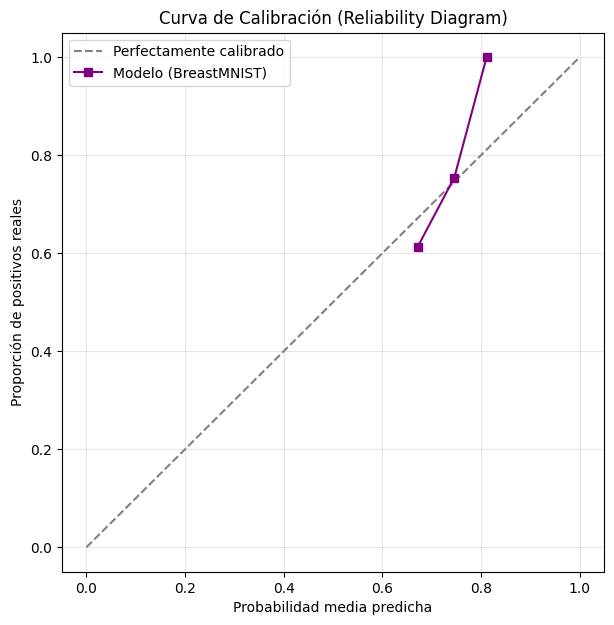

In [58]:
from sklearn.calibration import calibration_curve

model_breast.eval()
y_true_list = []
y_probs_list = []

with torch.no_grad():
    for x, y in test_loader_breast:
        x = x.to(device)
        outputs = model_breast(x)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        y_true_list.append(y.numpy())
        y_probs_list.append(probs.cpu().numpy())

y_true = np.concatenate(y_true_list).ravel()
y_probs = np.concatenate(y_probs_list)


prob_true, prob_pred = calibration_curve(y_true, y_probs, n_bins=10)

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectamente calibrado", color="gray")
plt.plot(prob_pred, prob_true, marker="s", label="Modelo (BreastMNIST)", color="purple")
plt.xlabel("Probabilidad media predicha")
plt.ylabel("Proporción de positivos reales")
plt.title("Curva de Calibración (Reliability Diagram)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Interpretación Clínica del Diagrama de Fiabilidad (Modelo BreastMNIST)

Este gráfico evalúa la confiabilidad clínica del modelo de red neuronal al clasificar imágenes de ultrasonido de mama (tejido maligno vs. benigno). Mide si la certeza matemática del modelo coincide con su verdadera tasa de acierto.

Línea Diagonal Punteada: Representa la calibración ideal. En la práctica clínica, si el modelo indica un "80% de probabilidad de tumor maligno", estadísticamente debería acertar en exactamente el 80% de esos casos.

Barras Azules (Precisión Real): Indican la tasa de acierto empírica del modelo en cada nivel de confianza (probabilidad predicha).

Zonas Rojas (Brecha de Sobreconfianza): Representan el exceso de seguridad de la red neuronal. Una zona roja amplia es un riesgo clínico, ya que indica que el modelo diagnosticó tumores con una certeza muy alta (ej. 90%), cuando en la realidad su precisión para esas imágenes fue significativamente menor. Minimizar esta zona previene diagnósticos falsamente seguros.

ECE (Expected Calibration Error): Es el indicador cuantitativo que resume estas zonas rojas. Un valor de ECE bajo (cercano a 0.000) confirma que los porcentajes de probabilidad que emite el modelo son altamente fiables y pueden utilizarse de forma segura como sistema de apoyo a la decisión médica para la detección de cáncer de mama.

/tmp/ipykernel_10865/1370445472.py:86: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  acc_patch = mpatches.Patch(color='royalblue', alpha=0.5, edgecolor='black', label='Outputs (Accuracy)')


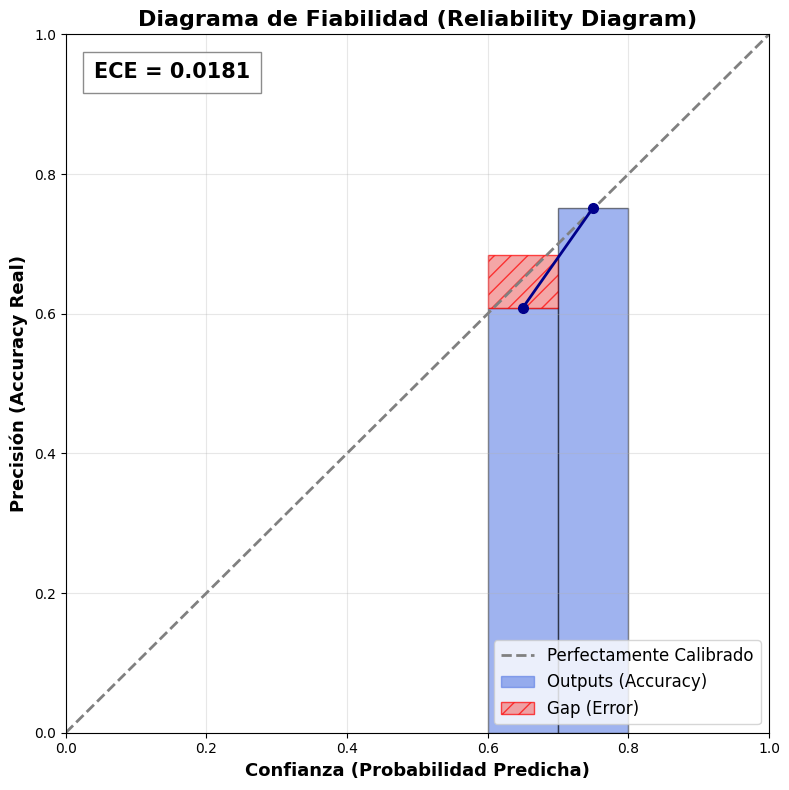

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch


model_breast.eval()
y_true_test = []
y_scores = []

with torch.no_grad():
    for x, y in test_loader_breast:
        x = x.to(device)
        outputs = model_breast(x)
        probs = torch.softmax(outputs, dim=1)
        y_scores.extend(probs[:, 1].cpu().numpy())
        y_true_test.extend(y.numpy().flatten())

y_true_test = np.array(y_true_test)
y_scores = np.array(y_scores)


n_bins = 10
bins = np.linspace(0.0, 1.0, n_bins + 1)

bin_accuracies = np.zeros(n_bins)
bin_confidences = np.zeros(n_bins)
bin_counts = np.zeros(n_bins)

for b in range(n_bins):

    if b == n_bins - 1:
        idx = (y_scores >= bins[b]) & (y_scores <= bins[b+1])
    else:
        idx = (y_scores >= bins[b]) & (y_scores < bins[b+1])

    if np.sum(idx) > 0:
        bin_accuracies[b] = np.mean(y_true_test[idx])
        bin_confidences[b] = np.mean(y_scores[idx])
        bin_counts[b] = np.sum(idx)


n_total = len(y_scores)
ece = np.sum(np.abs(bin_accuracies - bin_confidences) * (bin_counts / n_total))


fig, ax = plt.subplots(figsize=(8, 8))


ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=2, label='Calibración Perfecta')

bar_width = 1.0 / n_bins
bin_centers = bins[:-1] + bar_width / 2
valid_bins = bin_counts > 0


for b in range(n_bins):
    if bin_counts[b] > 0:

        ax.bar(bin_centers[b], bin_accuracies[b], width=bar_width,
               color='royalblue', alpha=0.5, edgecolor='black')


        if bin_confidences[b] > bin_accuracies[b]:
            gap = bin_confidences[b] - bin_accuracies[b]
            ax.bar(bin_centers[b], gap, bottom=bin_accuracies[b], width=bar_width,
                   color='lightcoral', alpha=0.7, hatch='//', edgecolor='red')


ax.plot(bin_centers[valid_bins], bin_accuracies[valid_bins], marker='o',
        color='darkblue', linewidth=2, markersize=7)


ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel('Confianza (Probabilidad Predicha)', fontsize=13, fontweight='bold')
ax.set_ylabel('Precisión (Accuracy Real)', fontsize=13, fontweight='bold')
ax.set_title('Diagrama de Fiabilidad (Reliability Diagram)', fontsize=16, fontweight='bold')


props = dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.04, 0.96, f'ECE = {ece:.4f}', transform=ax.transAxes, fontsize=15,
        verticalalignment='top', bbox=props, fontweight='bold')


acc_patch = mpatches.Patch(color='royalblue', alpha=0.5, edgecolor='black', label='Outputs (Accuracy)')
gap_patch = mpatches.Patch(facecolor='lightcoral', hatch='//', edgecolor='red', alpha=0.7, label='Gap (Error)')
perf_line = plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='Perfectamente Calibrado')
ax.legend(handles=[perf_line, acc_patch, gap_patch], loc='lower right', fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Interpretación Clínica de la Curva Precision-Recall (Modelo BreastMNIST)

Este gráfico evalúa el rendimiento del modelo enfocándose exclusivamente en su capacidad para detectar la clase minoritaria o de mayor interés clínico: los tumores malignos. Es la métrica ideal para evaluar el balance entre no omitir diagnósticos y no generar falsas alarmas.

Eje X (Recall / Sensibilidad): Mide la capacidad de "rastreo" del modelo. Indica qué porcentaje de los tumores malignos reales logró identificar. Un Recall alto es vital en medicina para asegurar que no se envíe a casa a un paciente enfermo (minimiza los falsos negativos).

Eje Y (Precision / Valor Predictivo Positivo): Mide la "certeza" de las alertas. Indica que, de todas las veces que el modelo diagnosticó un tumor como maligno, qué porcentaje realmente lo era. Una precisión alta evita biopsias innecesarias y estrés en pacientes sanos (minimiza falsos positivos).

Curva Azul: Representa el balance dinámico entre estas dos métricas. El escenario clínico perfecto es que la curva se mantenga pegada a la esquina superior derecha (detectar todos los tumores malignos con 100% de certeza).

AP = 0.96 (Average Precision): Es el indicador cuantitativo principal (el área bajo esta curva). Un valor de 0.96 demuestra un rendimiento sobresaliente. Significa que la red neuronal puede detectar la inmensa mayoría de los cánceres de mama en los ultrasonidos manteniendo una precisión casi perfecta, validando su utilidad como herramienta de apoyo diagnóstico.

Línea Punteada Inferior (No Skill): Representa el rendimiento equivalente a adivinar al azar según la prevalencia de los datos. La enorme distancia entre esta línea y la curva azul confirma que el modelo ha aprendido patrones radiológicos complejos.